# Mental Health Statistics Analysis


This notebook analyzes mental illness prevalence data using Python. It includes data cleaning, visualization, outlier detection, and statistical analysis.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [21]:
df = pd.read_csv('/kaggle/input/stat-project-mental-illneess-dataset/1- mental-illnesses-prevalence (1).csv')
df.head()

,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [22]:
df.columns = ['Country', 'Code', 'Year', 'Schizophrenia', 'Depression', 'Anxiety', 'Bipolar', 'Eating']

In [23]:
df.shape


(6420, 8)

In [24]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6420 entries, 0 to 6419
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        6420 non-null   object 
 1   Code           6150 non-null   object 
 2   Year           6420 non-null   int64  
 3   Schizophrenia  6420 non-null   float64
 4   Depression     6420 non-null   float64
 5   Anxiety        6420 non-null   float64
 6   Bipolar        6420 non-null   float64
 7   Eating         6420 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 401.4+ KB


In [25]:
df.describe()


,Year,Schizophrenia,Depression,Anxiety,Bipolar,Eating
count,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000
mean,2004.500000,0.266604,3.767036,4.101840,0.636968,0.195664
std,8.656116,0.039383,0.925286,1.050543,0.233391,0.138380
min,1990.000000,0.188416,1.522333,1.879996,0.181667,0.044780
25%,1997.000000,0.242267,3.080036,3.425846,0.520872,0.096416
50%,2004.500000,0.273477,3.636772,3.939547,0.579331,0.144150
75%,2012.000000,0.286575,4.366252,4.564164,0.844406,0.251167
max,2019.000000,0.462045,7.645899,8.624634,1.506730,1.031688


In [26]:
df.isnull().sum()


Country            0
Code             270
Year               0
Schizophrenia      0
Depression         0
Anxiety            0
Bipolar            0
Eating             0
dtype: int64

In [27]:
df_cleaned = df.dropna()
df_cleaned.head()


,Country,Code,Year,Schizophrenia,Depression,Anxiety,Bipolar,Eating
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


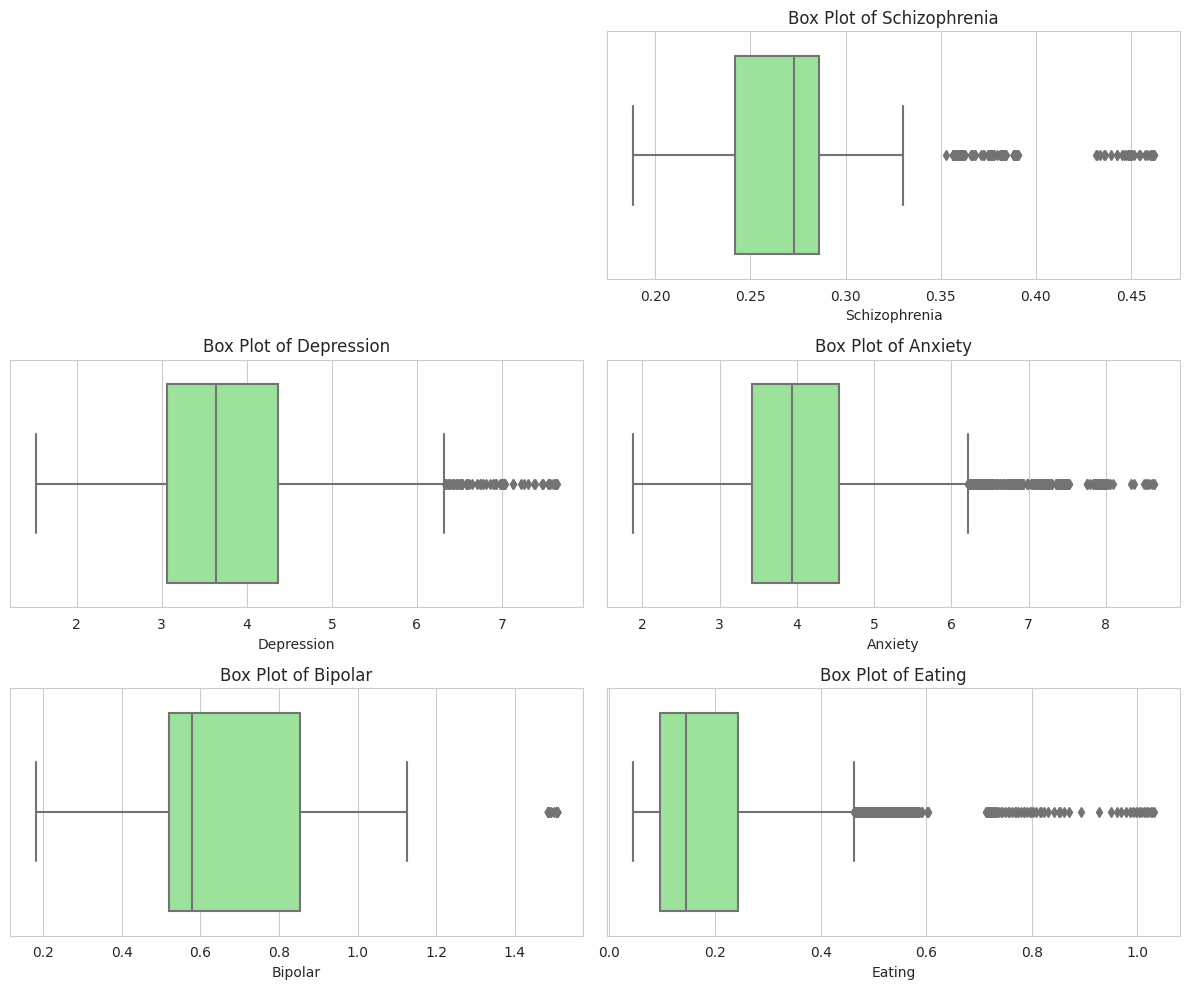

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
numerical_cols = df_cleaned.select_dtypes(include=["number"]).columns.tolist()

# Set Seaborn style
sns.set_style("whitegrid")

# Create box plots for each variable
plt.figure(figsize=(12, 10))

for i, col in enumerate(numerical_cols, 1):
    if col in ['Schizophrenia', 'Depression', 'Anxiety', 'Bipolar', 'Eating']:  # your variables
        plt.subplot(3, 2, i)  # 3 rows, 2 columns grid layout
        sns.boxplot(data=df_cleaned, x=col, color="lightgreen")
        plt.title(f"Box Plot of {col}")
        plt.xlabel(col)

plt.tight_layout()
plt.show()

In [39]:
# Copy the dataset to avoid modifying original
dataset_cleaned = df_cleaned.copy()

# Select only the numerical columns of interest
numeric_cols = ['Schizophrenia', 'Depression', 'Anxiety', 'Bipolar', 'Eating']

# Remove outliers using IQR method for each column
for col in numeric_cols:
    Q1 = dataset_cleaned[col].quantile(0.25)
    Q3 = dataset_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Keep only data within the IQR bounds
    dataset_cleaned = dataset_cleaned[
        (dataset_cleaned[col] >= lower_bound) & (dataset_cleaned[col] <= upper_bound)
    ]

# Print dataset shape before and after cleaning
print("Original dataset shape:", df_cleaned.shape)
print("Cleaned dataset shape:", dataset_cleaned.shape)

# Optionally preview the cleaned dataset
print(dataset_cleaned.head())

Original dataset shape: (6150, 8)
Cleaned dataset shape: (5099, 8)
       Country Code  Year  Schizophrenia  Depression   Anxiety   Bipolar  \
0  Afghanistan  AFG  1990       0.223206    4.996118  4.713314  0.703023   
1  Afghanistan  AFG  1991       0.222454    4.989290  4.702100  0.702069   
2  Afghanistan  AFG  1992       0.221751    4.981346  4.683743  0.700792   
3  Afghanistan  AFG  1993       0.220987    4.976958  4.673549  0.700087   
4  Afghanistan  AFG  1994       0.220183    4.977782  4.670810  0.699898   

     Eating  
0  0.127700  
1  0.123256  
2  0.118844  
3  0.115089  
4  0.111815  


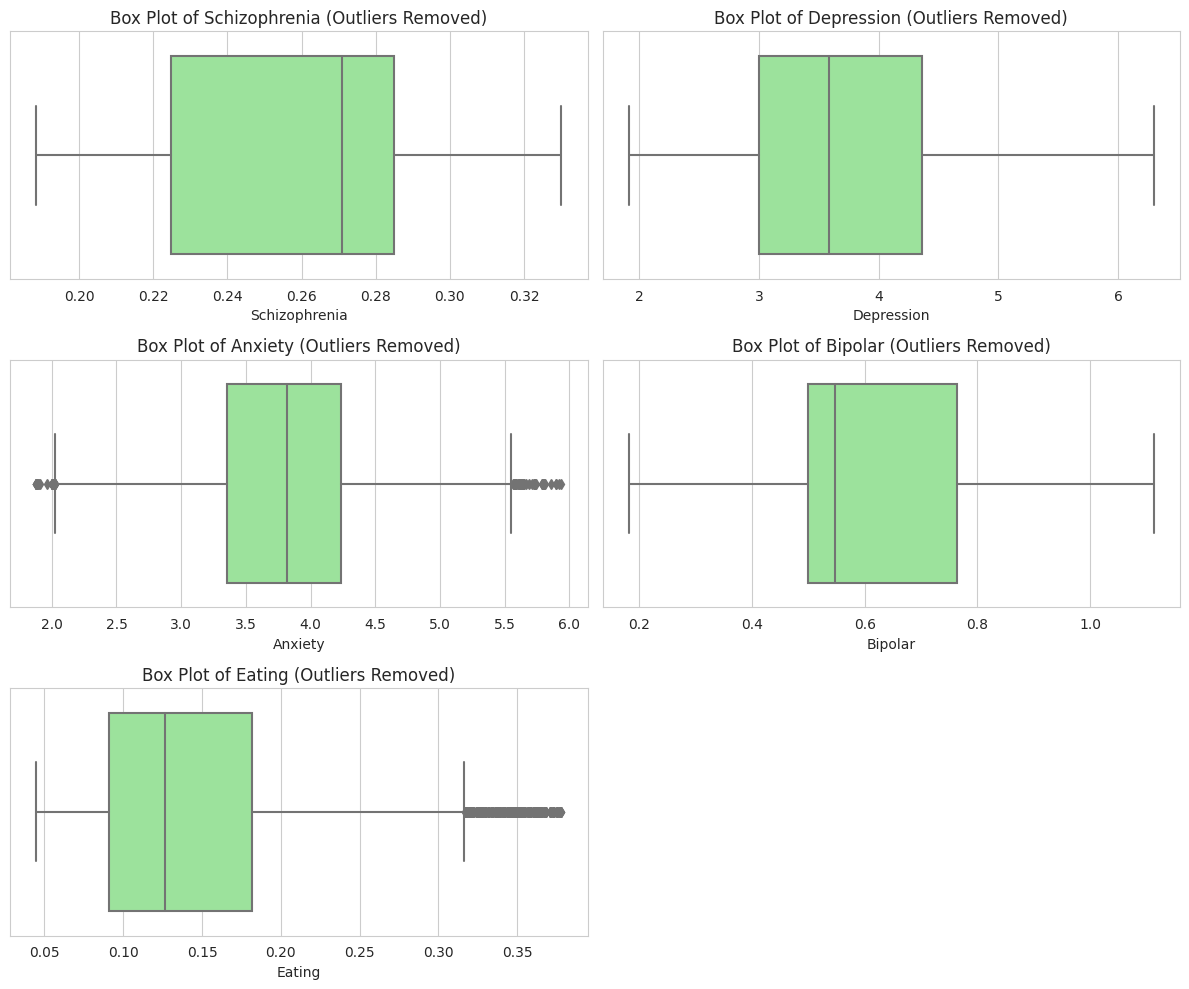

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set_style("whitegrid")

# Columns to plot
numeric_cols = ['Schizophrenia', 'Depression', 'Anxiety', 'Bipolar', 'Eating']

# Create box plots for each variable (3 rows, 2 columns layout)
plt.figure(figsize=(12, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=dataset_cleaned, x=col, color="lightgreen")
    plt.title(f"Box Plot of {col} (Outliers Removed)")
    plt.xlabel(col)
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [30]:
df_no_outliers['Country'].value_counts().head(10)

Country
Zimbabwe               30
Afghanistan            30
Albania                30
Algeria                30
American Samoa         30
Angola                 30
Antigua and Barbuda    30
Turkey                 30
Turkmenistan           30
Tuvalu                 30
Name: count, dtype: int64

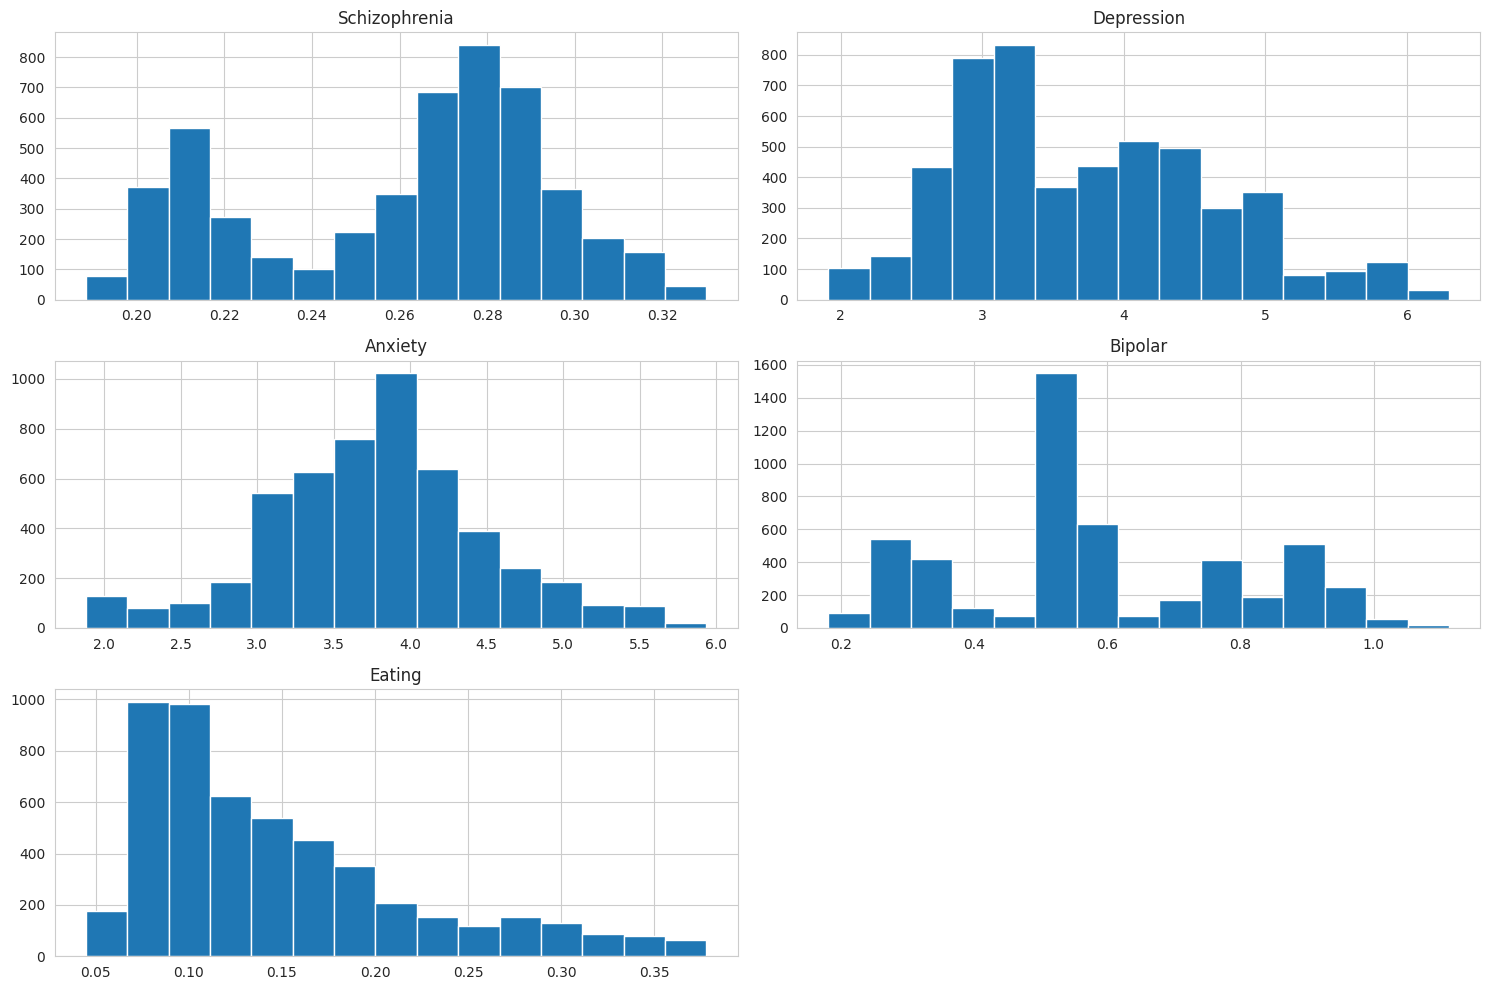

In [31]:
df_no_outliers[['Schizophrenia', 'Depression', 'Anxiety', 'Bipolar', 'Eating']].hist(bins=15, figsize=(15, 10))
plt.tight_layout()
plt.show()

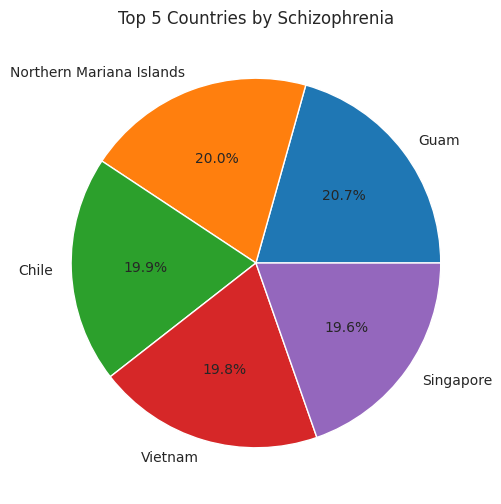

In [32]:
schiz_avg = df_no_outliers.groupby('Country')['Schizophrenia'].mean().sort_values(ascending=False).head(5)
schiz_avg.plot.pie(autopct='%1.1f%%', figsize=(8, 6), title='Top 5 Countries by Schizophrenia')
plt.ylabel('')
plt.show()

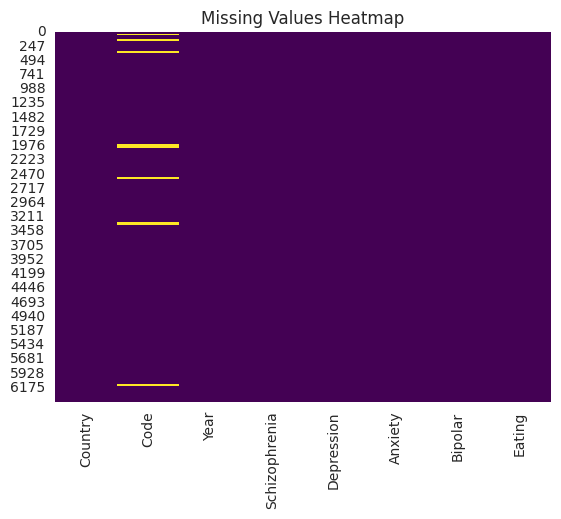

In [33]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

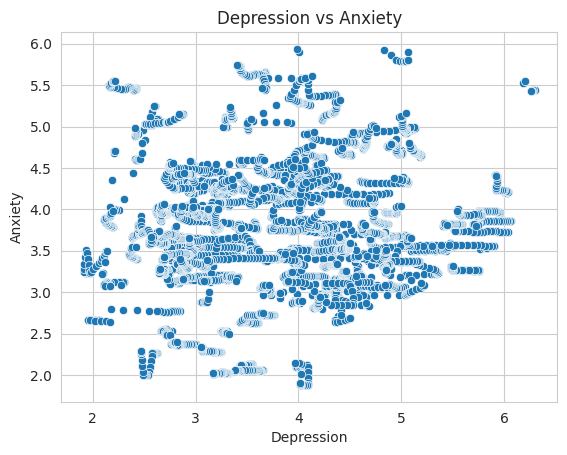

In [34]:
sns.scatterplot(data=df_no_outliers, x='Depression', y='Anxiety')
plt.title('Depression vs Anxiety')
plt.show()

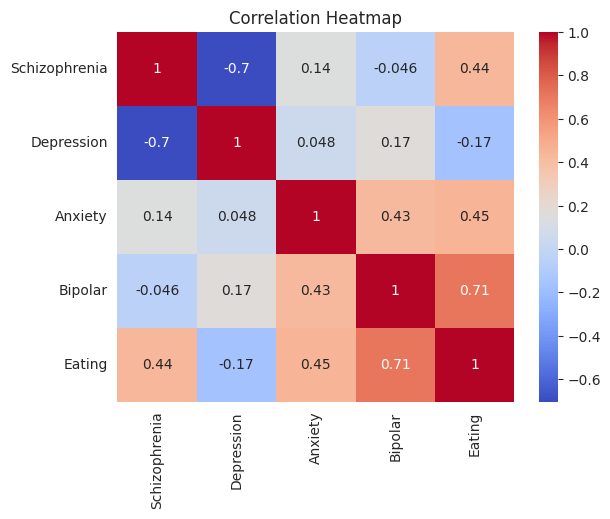

In [35]:
sns.heatmap(df_no_outliers[['Schizophrenia', 'Depression', 'Anxiety', 'Bipolar', 'Eating']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

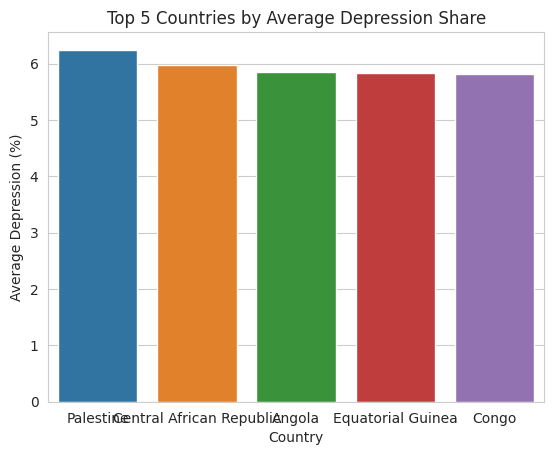

In [36]:
top_avg_dep = df_no_outliers.groupby('Country')['Depression'].mean().sort_values(ascending=False).head(5)
sns.barplot(x=top_avg_dep.index, y=top_avg_dep.values)
plt.title('Top 5 Countries by Average Depression Share')
plt.ylabel('Average Depression (%)')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

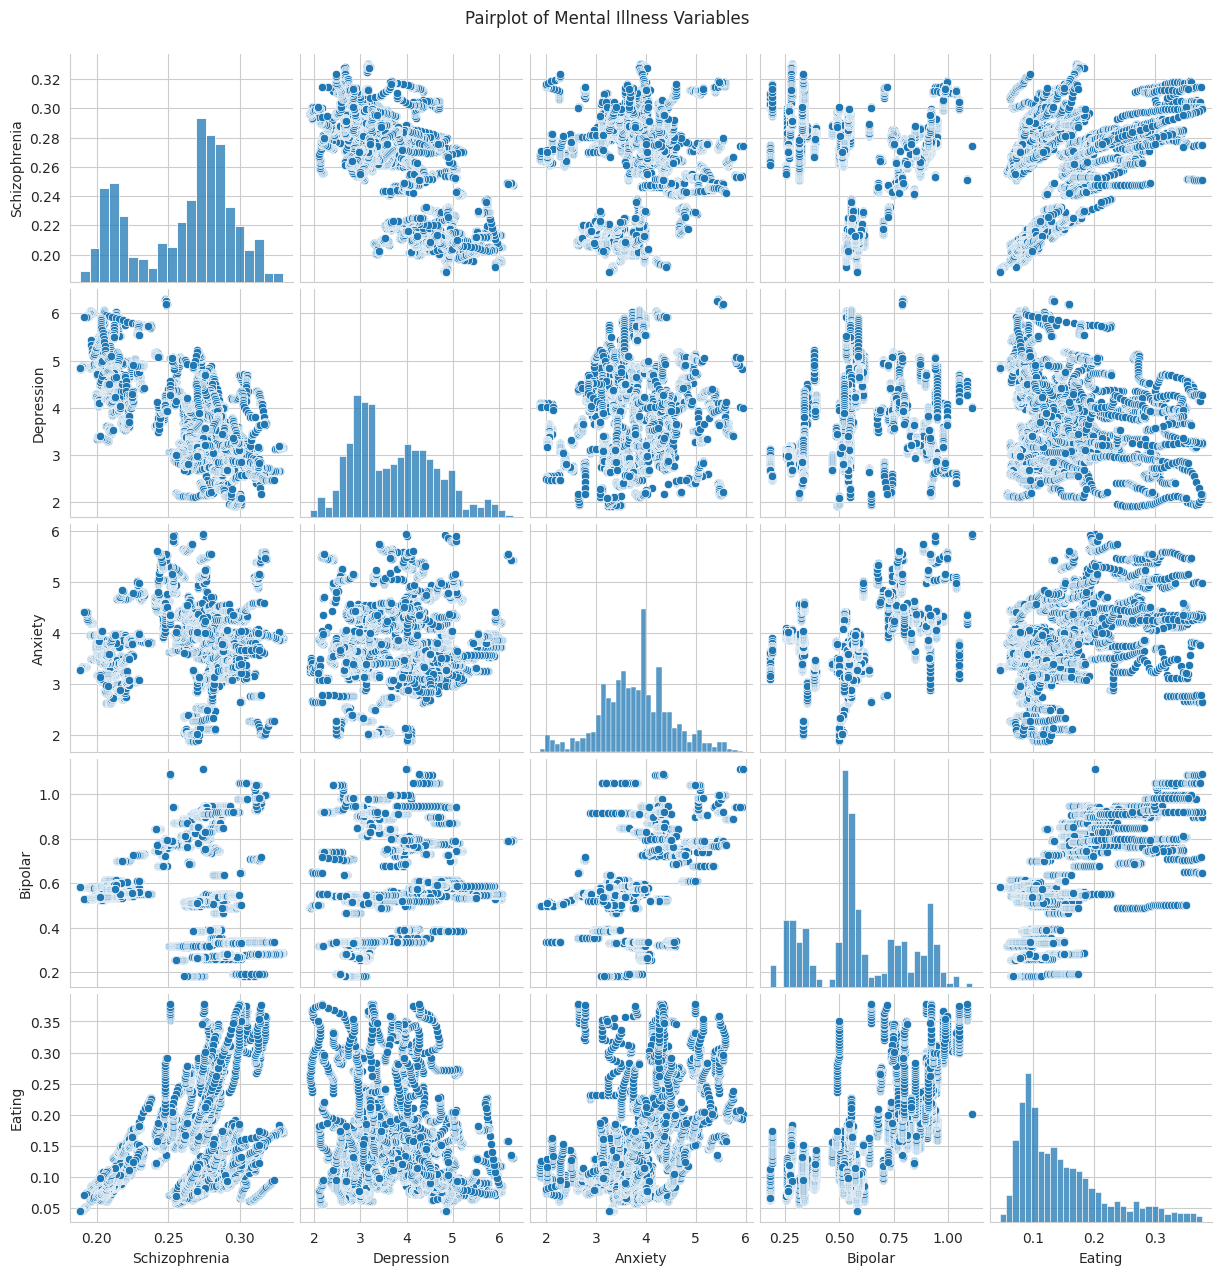

In [37]:
sns.pairplot(df_no_outliers[['Schizophrenia', 'Depression', 'Anxiety', 'Bipolar', 'Eating']])
plt.suptitle('Pairplot of Mental Illness Variables', y=1.02)
plt.show()